In [ ]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import os, json, math, random, pickle, shutil, socket, inspect, argparse, subprocess, warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

import librosa
from tqdm import tqdm
from IPython.display import Audio

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import datasets, transforms

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger

import umap
from sklearn.manifold import TSNE

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.mixture import GaussianMixture

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KernelDensity, NearestNeighbors
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, GroupKFold, train_test_split
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score,
    silhouette_score, silhouette_samples, davies_bouldin_score
)

import train
import commons
import models
import utils
import lightning_wrapper

from cough_datasets import (
    CoughDatasets,
    CoughDatasetsCollate,
    CoughDiseaseBinaryBatchSampler
)

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

In [ ]:
def _aprior(delta_hat: np.ndarray) -> np.ndarray:
    """ComBat EM prior: shape parameter for inverse gamma."""
    m = delta_hat.mean(axis=1)
    s2 = delta_hat.var(axis=1) + 1e-8
    return (2 * s2 + m**2) / s2


def _bprior(delta_hat: np.ndarray) -> np.ndarray:
    """ComBat EM prior: scale parameter for inverse gamma."""
    m = delta_hat.mean(axis=1)
    s2 = delta_hat.var(axis=1) + 1e-8
    return (m * s2 + m**3) / s2

def combat_harmonize(
    embeddings: np.ndarray,
    db_labels: np.ndarray,
    covariates: np.ndarray = None,
    n_iter: int = 30,
    conv_threshold: float = 1e-4,
) -> np.ndarray:
    """
    Empirical Bayes ComBat harmonization.
    
    Removes additive (gamma) and multiplicative (delta) batch effects
    while preserving biological signal via covariate design matrix.
    
    Parameters
    ----------
    embeddings   : (N, D) float array
    db_labels    : (N,) array of database IDs
    covariates   : (N, C) optional biological covariates to preserve
                   (e.g. disease_status encoded as 0/1)
    n_iter       : EM iterations for Bayesian shrinkage
    conv_threshold: convergence tolerance
    
    Returns
    -------
    harmonized   : (N, D) float array
    """
    N, D = embeddings.shape
    batches = np.unique(db_labels)
    n_batches = len(batches)
    
    # 1. Build design matrix
    # Intercept + covariates (biological signal to preserve)
    if covariates is not None:
        if covariates.ndim == 1:
            covariates = covariates.reshape(-1, 1)
        design = np.hstack([np.ones((N, 1)), covariates])
    else:
        design = np.ones((N, 1))
    
    # 2. Standardize overall
    grand_mean = embeddings.mean(axis=0)
    var_pooled = embeddings.var(axis=0) + 1e-8
    
    # 3. Regress out covariates to get residuals
    # Solve: embeddings = design @ B + residuals
    B, _, _, _ = np.linalg.lstsq(design, embeddings, rcond=None)
    residuals = embeddings - design @ B
    
    # 4. Standardize residuals
    stand_mean = (grand_mean / np.sqrt(var_pooled))
    s_data = (embeddings - grand_mean) / np.sqrt(var_pooled)
    
    # 5. Estimate batch effects (gamma_hat = additive, delta_hat = multiplicative)
    gamma_hat = np.zeros((n_batches, D))
    delta_hat = np.zeros((n_batches, D))
    
    batch_idx = {}
    for i, b in enumerate(batches):
        mask = db_labels == b
        batch_idx[i] = mask
        batch_data = s_data[mask]
        gamma_hat[i] = batch_data.mean(axis=0)
        delta_hat[i] = batch_data.var(axis=0) + 1e-8
    
    # 6. Empirical Bayes priors
    gamma_bar = gamma_hat.mean(axis=0)
    t2 = gamma_hat.var(axis=0) + 1e-8
    
    a_prior = _aprior(delta_hat)
    b_prior = _bprior(delta_hat)
    
    # 7. EM iteration for posterior estimates
    gamma_star = gamma_hat.copy()
    delta_star = delta_hat.copy()
    
    for _ in range(n_iter):
        gamma_star_new = np.zeros_like(gamma_hat)
        delta_star_new = np.zeros_like(delta_hat)
        
        for i, b in enumerate(batches):
            mask = batch_idx[i]
            n_i = mask.sum()
            batch_data = s_data[mask]
            
            # Posterior gamma (additive)
            gamma_star_new[i] = (
                (t2 * n_i * batch_data.mean(axis=0) + delta_star[i] * gamma_bar)
                / (t2 * n_i + delta_star[i])
            )
            
            # Posterior delta (multiplicative) via inverse gamma
            sum_sq = ((batch_data - gamma_star_new[i]) ** 2).sum(axis=0)
            delta_star_new[i] = (b_prior[i] + 0.5 * sum_sq) / (a_prior[i] + n_i / 2.0 - 1)
            delta_star_new[i] = np.maximum(delta_star_new[i], 1e-8)
        
        # Check convergence
        g_change = np.abs(gamma_star_new - gamma_star).max()
        d_change = np.abs(delta_star_new - delta_star).max()
        gamma_star = gamma_star_new
        delta_star = delta_star_new
        
        if g_change < conv_threshold and d_change < conv_threshold:
            break
    
    # 8. Apply correction
    harmonized = s_data.copy()
    for i, b in enumerate(batches):
        mask = batch_idx[i]
        harmonized[mask] = (
            (s_data[mask] - gamma_star[i]) / np.sqrt(delta_star[i])
        )
    
    # 9. Rescale back to original space
    harmonized = harmonized * np.sqrt(var_pooled) + grand_mean
    
    # Re-apply biological covariates
    harmonized = harmonized + design @ B - grand_mean
    
    return harmonized

def compute_mmd(X: np.ndarray, Y: np.ndarray, gamma: float = None) -> float:
    """
    Unbiased MMD² with RBF kernel.
    Lower = more similar distributions (better harmonization).
    """
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    
    def rbf_kernel(A, B):
        dists = np.sum((A[:, None] - B[None, :]) ** 2, axis=2)
        return np.exp(-gamma * dists)
    
    Kxx = rbf_kernel(X, X)
    Kyy = rbf_kernel(Y, Y)
    Kxy = rbf_kernel(X, Y)
    
    n, m = len(X), len(Y)
    mmd2 = (
        (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
        + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
        - 2 * Kxy.mean()
    )
    return float(mmd2)

def pairwise_mmd_matrix(embeddings: np.ndarray, db_labels: np.ndarray) -> pd.DataFrame:
    """Compute pairwise MMD between all database pairs."""
    batches = np.unique(db_labels)
    n = len(batches)
    matrix = np.zeros((n, n))
    
    for i, b1 in enumerate(batches):
        for j, b2 in enumerate(batches):
            if i != j:
                X = embeddings[db_labels == b1]
                Y = embeddings[db_labels == b2]
                # Subsample for speed if large
                if len(X) > 200: X = X[np.random.choice(len(X), 200, replace=False)]
                if len(Y) > 200: Y = Y[np.random.choice(len(Y), 200, replace=False)]
                matrix[i, j] = compute_mmd(X, Y)
    
    return pd.DataFrame(matrix, index=batches, columns=batches)

def get_classifiers() -> dict:
    """
    Return a dict of classifiers to compare.
    All wrapped in a Pipeline with StandardScaler + PCA for fair comparison.
    PCA(50) reduces 768-dim embeddings to a stable space for all classifiers.
    """
    pca_step = ("pca", PCA(n_components=50, random_state=42))
    scale_step = ("scaler", StandardScaler())

    return {
        "Logistic Regression": Pipeline([
            scale_step, pca_step,
            ("clf", LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
        ]),
        "Neural Network (MLP)": Pipeline([
            scale_step,
            pca_step,
            ("clf", MLPClassifier(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size=64,
                learning_rate_init=1e-3,
                max_iter=300,
                early_stopping=True,
                random_state=42
            )),
        ]),
        "SVM (RBF)": Pipeline([
            scale_step, pca_step,
            ("clf", SVC(kernel="rbf", probability=True, C=1.0, random_state=42)),
        ]),
        "Random Forest": Pipeline([
            scale_step, pca_step,
            ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ]),
        "Gradient Boosting": Pipeline([
            scale_step, pca_step,
            ("clf", GradientBoostingClassifier(n_estimators=200, random_state=42)),
        ]),
    }

def run_embedding_classification(
    df,
    train_db,
    test_dbs=None,
    embed_col="embed",
    label_col="disease_status",
    participant_col="participant",
    db_col="db",
    n_splits=5,
    classifiers=None
):
    """
    Flexible evaluation pipeline for embedding-based classification.

    Parameters
    ----------
    df : DataFrame
        Combined dataframe containing embeddings and metadata.
    train_db : int or list
        DB id(s) used for training + cross-validation.
    test_dbs : list or None
        DB ids used as external evaluation sets.
    embed_col : str
        Column containing embeddings.
    label_col : str
        Label column.
    participant_col : str
        Column used for GroupKFold grouping.
    db_col : str
        Database identifier column.
    n_splits : int
        Number of CV folds.
    classifiers : dict
        Dict of sklearn classifiers.

    Returns
    -------
    results : dict
        Mean and std metrics across folds for each classifier.
    """

    if classifiers is None:
        classifiers = get_classifiers()

    if not isinstance(train_db, list):
        train_db = [train_db]

    if test_dbs is None:
        test_dbs = []

    df_train = df[df[db_col].isin(train_db)].copy()

    X = np.vstack(df_train[embed_col].values).astype(np.float32)
    y = df_train[label_col].astype(int).values
    groups = df_train[participant_col].values

    external_sets = {}
    for db in test_dbs:
        df_ext = df[df[db_col] == db]
        X_ext = np.vstack(df_ext[embed_col].values).astype(np.float32)
        y_ext = df_ext[label_col].astype(int).values
        external_sets[db] = (X_ext, y_ext)

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    splits = list(cv.split(X, y, groups=groups))

    model_results = {}
    for clf_name, clf in tqdm(classifiers.items(), desc="Training classifiers"):
        fold_aurocs = []
        fold_aurocs_ext = {db: [] for db in test_dbs}

        for train_idx, test_idx in splits:
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            clf.fit(X_train, y_train)

            y_score = clf.predict_proba(X_test)[:, 1]
            fold_aurocs.append(roc_auc_score(y_test, y_score))

            for db in test_dbs:
                X_ext, y_ext = external_sets[db]
                y_score_ext = clf.predict_proba(X_ext)[:, 1]
                fold_aurocs_ext[db].append(roc_auc_score(y_ext, y_score_ext))

        model_results[clf_name] = {
            "auroc": np.mean(fold_aurocs),
            **{f"auroc_db{db}": np.mean(vals) for db, vals in fold_aurocs_ext.items()}
        }

    # -------- aggregate across models --------

    all_aurocs = [v["auroc"] for v in model_results.values()]

    summary = {
        "mean_auroc_all_models": np.mean(all_aurocs),
        "std_auroc_all_models": np.std(all_aurocs)
    }

    for db in test_dbs:
        vals = [v[f"auroc_db{db}"] for v in model_results.values()]
        summary[f"mean_auroc_db{db}_all_models"] = np.mean(vals)
        summary[f"std_auroc_db{db}_all_models"] = np.std(vals)

    return summary, model_results

def _sigmoid_normalize(scores: np.ndarray) -> np.ndarray:
    """Center and sigmoid-normalize scores to [0, 1]."""
    centered = (scores - scores.mean()) / (scores.std() + 1e-8)
    return 1.0 / (1.0 + np.exp(-centered))

def _minmax_normalize(scores: np.ndarray) -> np.ndarray:
    lo, hi = scores.min(), scores.max()
    return (scores - lo) / (hi - lo + 1e-8)

def best_gmm(data, max_k=6, random_state=42):
    best_bic, best_k = np.inf, 1
    max_k = min(max_k, len(data) // 20)  # need enough samples per component
    max_k = max(max_k, 1)
    for k in range(1, max_k + 1):
        try:
            g = GaussianMixture(n_components=k, covariance_type="diag", random_state=random_state, n_init=3)
            g.fit(data)
            bic = g.bic(data)
            if bic < best_bic:
                best_bic, best_k = bic, k
        except Exception:
            break
    gmm = GaussianMixture(n_components=best_k, covariance_type="diag",
                            random_state=random_state, n_init=5)
    gmm.fit(data)
    print(f"    GMM components selected (BIC): {best_k}")
    return gmm

def find_optimal_k(
    embeddings: np.ndarray,
    k_range: range = None,
    method: str = "silhouette",
    random_state: int = 42,
) -> tuple[int, pd.DataFrame]:
    """
    Find optimal number of clusters via silhouette + elbow analysis.
    
    Returns
    -------
    best_k     : recommended number of clusters
    metrics_df : per-k metrics table
    """
    if k_range is None:
        k_range = range(2, min(8, len(embeddings) // 10 + 1))
    
    pca = PCA(n_components=min(50, embeddings.shape[1]), random_state=random_state)
    emb_pca = pca.fit_transform(embeddings)
    
    records = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=random_state)
        labels = km.fit_predict(emb_pca)
        
        sil = silhouette_score(emb_pca, labels)
        inertia = km.inertia_
        db = davies_bouldin_score(emb_pca, labels)
        records.append({"k": k, "silhouette": sil, "inertia": inertia, "davies_bouldin": db})
    
    df = pd.DataFrame(records)
    
    # Best k = highest silhouette (or use elbow)
    best_k = int(df.loc[df["silhouette"].idxmax(), "k"])
    
    return best_k, df

def cluster_within_class(
    embeddings: np.ndarray,
    class_labels: np.ndarray,
    target_class,
    n_clusters: int = None,
    method: str = "kmeans",
    random_state: int = 42,
) -> tuple[np.ndarray, KMeans, pd.DataFrame]:
    """
    Cluster samples within a specific class (e.g., TB only).
    
    Returns
    -------
    cluster_labels : (N_class,) cluster assignments
    model          : fitted clustering model
    k_metrics      : cluster quality metrics
    """
    mask = class_labels == target_class
    subset = embeddings[mask]
    
    pca = PCA(n_components=min(30, subset.shape[1]), random_state=random_state)
    subset_pca = pca.fit_transform(subset)
    
    if n_clusters is None:
        print(f"    Auto-selecting k for class '{target_class}'...")
        n_clusters, k_metrics = find_optimal_k(subset, random_state=random_state)
        print(f"    → Optimal k = {n_clusters}")
    else:
        k_metrics = pd.DataFrame()
    
    if method == "kmeans":
        model = KMeans(n_clusters=n_clusters, n_init=20, random_state=random_state)
        cluster_labels = model.fit_predict(subset_pca)
    elif method == "gmm":
        model = GaussianMixture(n_components=n_clusters, random_state=random_state,
                                covariance_type="full", n_init=5)
        cluster_labels = model.fit_predict(subset_pca)
    
    return cluster_labels, model, k_metrics, pca

In [ ]:
# from s3prl.upstream.mockingjay.builder import PretrainedTransformer
# from s3prl.upstream.mockingjay.model import TransformerSpecPredictionHead
# import s3prl.optimizers
# import sys
# original_optimizer = sys.modules.get("optimizers")
# sys.modules["optimizers"] = s3prl.optimizers

# class TERA_TryDownstream(nn.Module):
#     def __init__(self, input_size, **kwargs):
#         super(TERA_TryDownstream, self).__init__()

#         options = {
#             "load_pretrain": "True",
#             "no_grad": "True",
#             "dropout": "default",
#             "spec_aug": "False",
#             "spec_aug_prev": "False",
#             "output_hidden_states": "True",
#             "permute_input": "False",
#         }
#         options["ckpt_file"] = "/run/media/fourier/Data1/Pras/Thesis_Nexus/s3prl/s3prl/result/pretrain/tera_cough_ssldata_lowlr/states-990000.ckpt"
#         options["select_layer"] = -1
        
#         pretrained_dict = torch.load(options["ckpt_file"], weights_only=False)
#         transformer_state = pretrained_dict['Transformer']
#         spechead_state = pretrained_dict['SpecHead']

#         self.tera_model = PretrainedTransformer(options, inp_dim=-1)
#         self.tera_model.model.load_state_dict(transformer_state, strict=True)
#         self.tera_model.eval()

#         self.spechead_model = TransformerSpecPredictionHead(self.tera_model.model_config, self.tera_model.spec_dim)
#         self.spechead_model.load_state_dict(spechead_state, strict=True)
#         self.spechead_model.eval()

#     def forward(self, x, attention_mask=None, grl_lambda=0.0):
#         x = x.squeeze(1)
#         with torch.no_grad():
#             x = self.tera_model(x)[0] # Index 0 = Last Hidden, Index 1 All Transformwer
#             x = torch.nan_to_num(x, nan=0.0)
#             reconstructed_mel, _ = self.spechead_model(x)
#             reconstructed_mel = reconstructed_mel.transpose(1, 2)

#         mean = x.mean(dim=1)
#         std = x.std(dim=1)
#         feature_embedding = torch.cat([mean, std], dim=1)
#         return {
#             "embeddings": feature_embedding,
#             "reconstructed_mel": reconstructed_mel,
#         }
    
# model = TERA_TryDownstream(1)
# model.cuda()
# model.eval()

# del sys.modules["optimizers"]

class Qwen3_Extractor(nn.Module):
    def __init__(self, dummy, **kwargs):
        super(Qwen3_Extractor, self).__init__()

        from transformers import Qwen3OmniMoeThinkerForConditionalGeneration
        temp_model = Qwen3OmniMoeThinkerForConditionalGeneration.from_pretrained(
            "/run/media/fourier/Data1/Pras/pretrain_models/Qwen3-Omni-30B-A3B-Thinking",
            torch_dtype="auto",
            device_map="cpu"
        )
        self.audio_tower = temp_model.audio_tower
        self.audio_tower.cuda()
        del temp_model
        import gc
        import torch
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        self.audiotower_hidden_dim = self.audio_tower.config.output_dim

    def after_cnn_len(self, L):
        L = (L - 1) // 2 + 1
        L = (L - 1) // 2 + 1
        L = (L - 1) // 2 + 1
        return L

    def forward(self, input_features, attention_mask=None, **kwargs):
        input_features = input_features.to(torch.bfloat16)
        feature_attention_mask = attention_mask.long()
        if feature_attention_mask is not None:
            audio_feature_lengths = torch.sum(feature_attention_mask, dim=1)
            input_features = input_features.permute(
                0, 2, 1)[feature_attention_mask.bool()].permute(1, 0)
        else:
            audio_feature_lengths = None

        feature_lens = audio_feature_lengths if audio_feature_lengths is not None else feature_attention_mask.sum(-1)
        audio_outputs = self.audio_tower(
            input_features,
            feature_lens=feature_lens,
        )
        audio_features = audio_outputs.last_hidden_state
        post_lens = torch.tensor(
            [self.after_cnn_len(l.item()) for l in feature_lens],
            device=feature_lens.device
        )

        total = audio_features.size(0)
        delta = total - post_lens.sum()
        if delta != 0:
            post_lens[-1] += delta

        audio_features = audio_features.split(post_lens.tolist(), dim=0)
        audio_features = pad_sequence(audio_features, batch_first=True) # for Attentive Pooling
        audio_features = audio_features.to(torch.float32)

        mean = audio_features.mean(dim=1)
        std = audio_features.std(dim=1)

        embeddings = torch.cat([mean, std], dim=1)
        return {
            "embeddings": embeddings,
        }

model = Qwen3_Extractor(1)
model.cuda()
model.eval()

parser = train.parse_args()
args = parser.parse_args(["--init", "--model_name", "dev", "--pooling_model",
                          "qwen", "--config_path", "configs/general.json"]) # qwen

model_dir = os.path.join("./logs", args.model_name)
os.makedirs(model_dir, exist_ok=True)
port = None

config_path = args.config_path if args.init else os.path.join(model_dir, "config.json")
hps = train.load_config(config_path, model_dir, args)

df_train, _ = train.load_data(hps)
collate_fn = train.get_collate_fn(hps)
target_labels = df_train[hps.data.target_column]

_, coda_loader = train.prepare_fold_data(
    df_train, df_train, hps, collate_fn,
    use_precomputed=args.use_precomputed,
    precomputed_dir=args.precomputed_dir
)

df_cirdz = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata_cirdz.csv.train')
df_cirdz = df_cirdz.reset_index(drop=True)
df_cirdz = df_cirdz[hps.data.column_order]

_, cirdz_loader = train.prepare_fold_data(
    df_cirdz, df_cirdz, hps, collate_fn,
    use_precomputed=args.use_precomputed,
    precomputed_dir=args.precomputed_dir
)

df_ukcovid = pd.read_csv(f'/run/media/fourier/Data1/Pras/DatabaseLLM/ukcovid19/metadata.csv.train')
df_ukcovid[["weight_loss", "hemoptysis", "night_sweats", "smoker"]] = 0
df_ukcovid = df_ukcovid.rename(columns={"path_file_audio": "path_file", "participant_identifier": "participant", "covid_test_result": "disease_status"})
df_ukcovid["gender"] = df_ukcovid["gender"].map({"Male": 0, "Female": 1})
df_ukcovid["disease_status"] = df_ukcovid["disease_status"].map({4: 0})
df_ukcovid["participant"] = df_ukcovid["participant"].str.lstrip("P").astype(int)
df_ukcovid = df_ukcovid.dropna().reset_index(drop=True)
#df_ukcovid = df_ukcovid.sample(n=12693, random_state=42).reset_index(drop=True)
df_ukcovid = df_ukcovid[hps.data.column_order]

_, ukcovid_loader = train.prepare_fold_data(
    df_ukcovid, df_ukcovid, hps, collate_fn,
    use_precomputed=args.use_precomputed,
    precomputed_dir=args.precomputed_dir
)

In [ ]:
train_embeds = []
train_wavs = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(coda_loader), total=len(coda_loader)):
        wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _, tabular_ids, _]  = batch
        audio = audio.cuda()
        out_model = model(audio, attention_mask=attention_masks)
        embed = out_model['embeddings']

        dse_ids = torch.argmax(dse_ids, dim=1)
        train_wavs.extend(wavs_names)
        train_embeds.append(embed.cpu())

train_wavs = np.array(train_wavs)
train_embeds = torch.cat(train_embeds, dim=0).numpy()

df_train = df_train.set_index("path_file").loc[train_wavs].reset_index()
df_train["embed"] = list(train_embeds)
df_train["db"] = 0

train_embeds = []
train_wavs = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(cirdz_loader), total=len(cirdz_loader)):
        wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _, tabular_ids, _]  = batch
        audio = audio.cuda()
        out_model = model(audio, attention_mask=attention_masks)
        embed = out_model['embeddings']

        dse_ids = torch.argmax(dse_ids, dim=1)
        train_wavs.extend(wavs_names)
        train_embeds.append(embed.cpu())

train_wavs = np.array(train_wavs)
train_embeds = torch.cat(train_embeds, dim=0).numpy()

df_cirdz = df_cirdz.set_index("path_file").loc[train_wavs].reset_index()
df_cirdz["embed"] = list(train_embeds)
df_cirdz["db"] = 1

train_embeds = []
train_wavs = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(ukcovid_loader), total=len(ukcovid_loader)):
        wavs_names, audio, _, attention_masks, dse_ids, [patient_ids, _, tabular_ids, _]  = batch
        audio = audio.cuda()
        out_model = model(audio, attention_mask=attention_masks)
        embed = out_model['embeddings']

        dse_ids = torch.argmax(dse_ids, dim=1)
        train_wavs.extend(wavs_names)
        train_embeds.append(embed.cpu())

train_wavs = np.array(train_wavs)
train_embeds = torch.cat(train_embeds, dim=0).numpy()

df_ukcovid = df_ukcovid.set_index("path_file").loc[train_wavs].reset_index()
df_ukcovid["embed"] = list(train_embeds)
df_ukcovid["db"] = 2

df_combine = pd.concat([df_train, df_cirdz, df_ukcovid]).reset_index(drop=True)

In [ ]:
summary, model_results = run_embedding_classification(
    df_combine,
    train_db=0,
    test_dbs=[1],
    label_col="disease_status",
)
summary

## COMBAT

In [ ]:
raw_emb = np.stack(df_combine['embed'].values)
db_labels = df_combine['db'].values
disease_labels = df_combine['disease_status'].values

N, D = raw_emb.shape
print(f"  Embeddings: {N} samples × {D} dims")
print(f"  Databases : {dict(zip(*np.unique(db_labels, return_counts=True)))}")
print(f"  Disease   : {dict(zip(*np.unique(disease_labels, return_counts=True)))}")

In [6]:
covariates = disease_labels.astype(float).reshape(-1, 1)
combat_emb = combat_harmonize(raw_emb, db_labels, covariates=None)
embeddings = {"raw": raw_emb, "ComBat": combat_emb}

mmd_raw = pairwise_mmd_matrix(raw_emb, db_labels)
mmd_combat = pairwise_mmd_matrix(combat_emb, db_labels)
print({
    "Raw":     mmd_raw.values[mmd_raw.values > 0].mean(),
    "ComBat":  mmd_combat.values[mmd_combat.values > 0].mean(),
})

r2_result = {}
for name, emb in embeddings.items():
    pca = PCA(n_components=50, random_state=42)
    pcs = pca.fit_transform(emb)

    r2_db = Ridge().fit(db_labels.reshape(-1, 1), pcs).score(db_labels.reshape(-1, 1), pcs)
    r2_dis = Ridge().fit(disease_labels.reshape(-1, 1), pcs).score(disease_labels.reshape(-1, 1), pcs)
    r2_result[name] = {
        "r2_db": r2_db,
        "r2_dis": r2_dis,
    }
r2_result

{'Raw': 9.645114591975516e-05, 'ComBat': 4.117555104284539e-08}


{'raw': {'r2_db': 0.019550353055107633, 'r2_dis': 0.005036957228970329},
 'ComBat': {'r2_db': 4.05006764570004e-09, 'r2_dis': 0.0009050408645282904}}

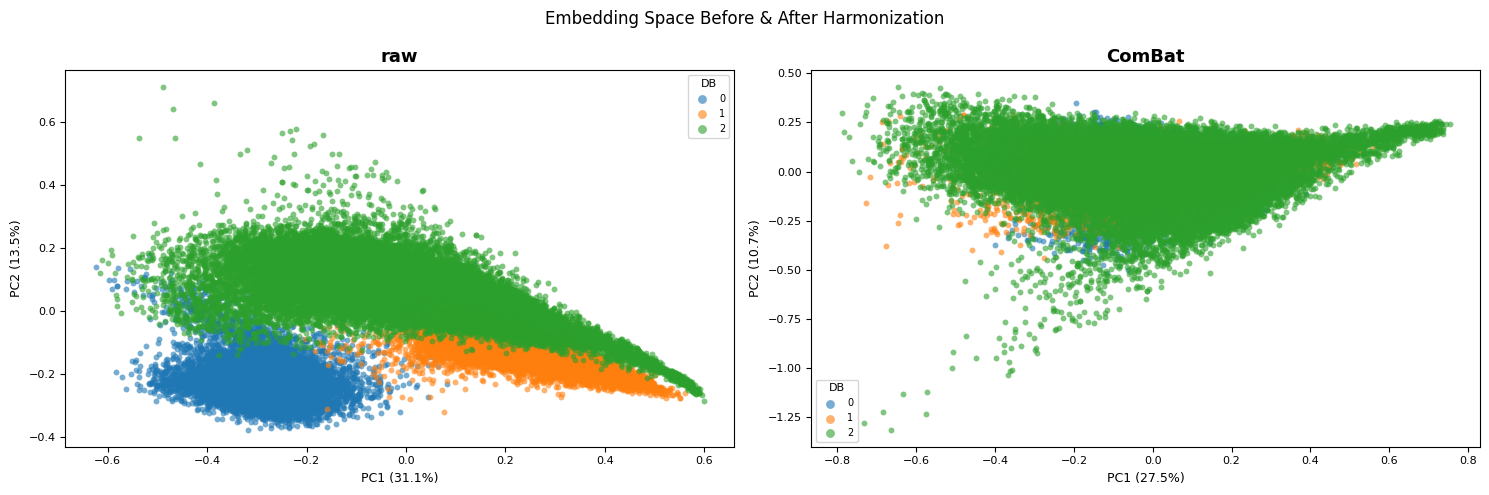

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Embedding Space Before & After Harmonization")

for col, (name, emb) in enumerate(embeddings.items()):
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(emb)
    var1, var2 = pca.explained_variance_ratio_ * 100

    ax = axes[col]
    unique_dbs = np.unique(db_labels)
    for db in unique_dbs:
        mask = db_labels == db
        ax.scatter(pcs[mask, 0], pcs[mask, 1], label=str(db), alpha=0.6, s=18, linewidths=0)
    ax.set_title(f"{name}", fontsize=13, fontweight="bold")
    ax.set_xlabel(f"PC1 ({var1:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({var2:.1f}%)", fontsize=9)
    ax.legend(fontsize=7, markerscale=1.5, title="DB", title_fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
fig.savefig(
    "docs/unsupervised_distri/figures/combat.png",
    dpi=300,
    bbox_inches="tight"
)

In [8]:
df_combine["embed"] = list(combat_emb)

In [ ]:
summary, model_results = run_embedding_classification(
    df_combine,
    train_db=0,
    test_dbs=[1],
    label_col="disease_status",
)
summary

## Outlier

In [9]:
raw_emb = np.stack(df_combine['embed'].values)
db_labels = df_combine['db'].values
disease_labels = df_combine['disease_status'].values

In [10]:
contamination = 0.01
pca = PCA(n_components=min(50, raw_emb.shape[1]), random_state=42)
emb_pca = pca.fit_transform(raw_emb)

# ─────────────────────────────────────────────
# METHOD A: Isolation Forest
# ─────────────────────────────────────────────
clf = IsolationForest(
    n_estimators=200,
    contamination=contamination, # Expected fraction of outliers 5%
    random_state=42,
    n_jobs=-1,
)
clf.fit_predict(emb_pca)        # 1 = inlier, -1 = outlier
if_scores = clf.score_samples(emb_pca)      # lower = more anomalous
if_scores = -if_scores  # IF scores are negative; negate so high = bad
if_scores = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min() + 1e-8)

# ─────────────────────────────────────────────
# METHOD B: Per-Class Centroid Distance
# ─────────────────────────────────────────────
threshold_sigma = 2.5 # threshold_sigma  : SD multiplier for outlier boundary
distances = np.zeros(len(raw_emb))
unique_classes = np.unique(db_labels)

for cls in unique_classes:
    mask = db_labels == cls
    subset = emb_pca[mask]
    centroid = subset.mean(axis=0)
    
    # Euclidean distance from centroid
    dists = np.linalg.norm(subset - centroid, axis=1)
    
    # Normalize by median (robust to outliers in the distance distribution)
    median_dist = np.median(dists)
    mad = np.median(np.abs(dists - median_dist)) + 1e-8  # Median Absolute Deviation
    normalized = (dists - median_dist) / mad
    distances[mask] = normalized # sigma

cd_norm = np.clip(distances, 0, None)  # remove negative (inlier side)
cd_norm = (cd_norm - cd_norm.min()) / (cd_norm.max() - cd_norm.min() + 1e-8)

# Ensemble
ensemble_scores = 0.5 * if_scores + 0.5 * cd_norm
threshold = np.percentile(ensemble_scores, 100 * (1 - contamination))
outlier_labels = np.where(ensemble_scores >= threshold, -1, 1)

outlier_mask = outlier_labels == -1
inlier_mask = outlier_labels == 1
n_outliers = outlier_mask.sum()
print(f"  outliers: {n_outliers} ({outlier_mask.mean()*100:.1f}%)")

  outliers: 639 (1.0%)


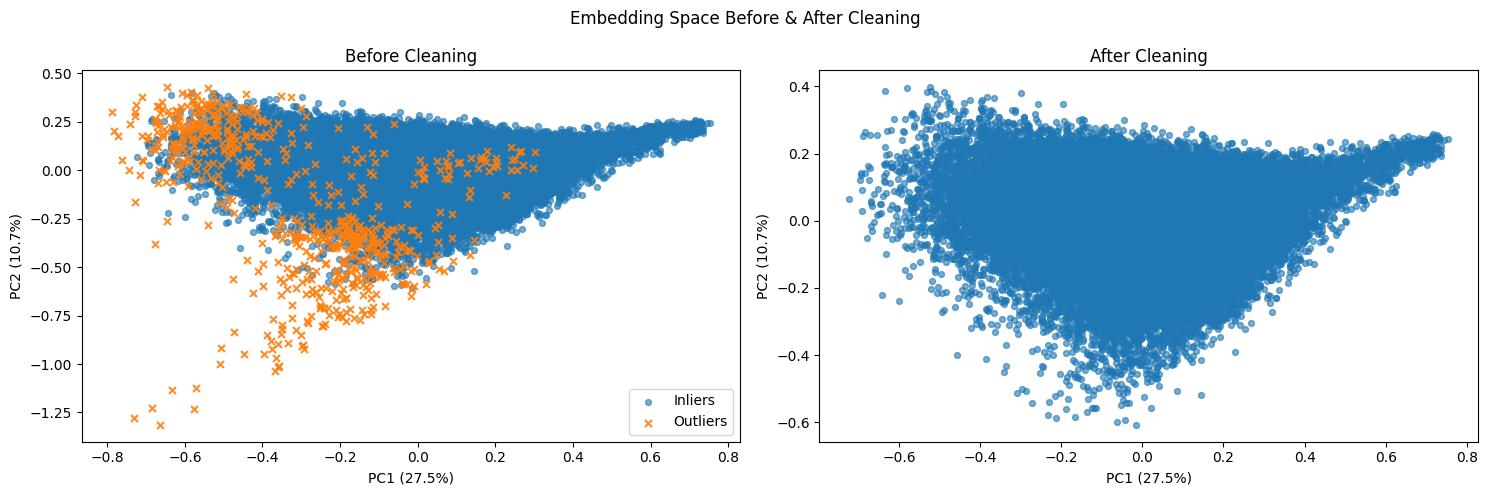

In [11]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(raw_emb)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle("Embedding Space Before & After Cleaning")

# BEFORE
ax = axes[0]
ax.scatter(pcs[inlier_mask,0], pcs[inlier_mask,1], s=18, alpha=0.6, label="Inliers")
ax.scatter(pcs[~inlier_mask,0], pcs[~inlier_mask,1], s=25, alpha=0.9, marker="x", label="Outliers")

ax.set_title("Before Cleaning")
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")
ax.legend()

# AFTER
ax = axes[1]
ax.scatter(pcs[inlier_mask,0], pcs[inlier_mask,1], s=18, alpha=0.6)

ax.set_title("After Cleaning")
ax.set_xlabel(f"PC1 ({var1:.1f}%)")
ax.set_ylabel(f"PC2 ({var2:.1f}%)")

plt.tight_layout()
fig.savefig(
    "docs/unsupervised_distri/figures/outlier.png",
    dpi=300,
    bbox_inches="tight"
)

In [12]:
df_combine = df_combine[~outlier_mask].reset_index(drop=True)

In [ ]:
summary, model_results = run_embedding_classification(
    df_combine,
    train_db=0,
    test_dbs=[1],
    label_col="disease_status",
)
summary

## Intra Classs

In [81]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import WeightedRandomSampler

class EmbeddingDataset(Dataset):
    def __init__(self, X, y, db):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.db = torch.tensor(db, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            self.X[idx],
            self.y[idx],
            self.db[idx]
        )

class ProjectionHead(nn.Module):
    def __init__(self, in_dim=768, hidden=256, out_dim=32):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )

    def forward(self, x):
        z = self.net(x)
        z = F.normalize(z, dim=1)
        return z
    
class PrototypeModel(nn.Module):
    def __init__(self, in_dim=768, proj_dim=128, n_proto=16):
        super().__init__()

        self.encoder = ProjectionHead(in_dim, 256, proj_dim)
        self.prototypes = nn.Parameter(torch.randn(n_proto, proj_dim))

    def forward(self, x):
        z = self.encoder(x)
        proto = F.normalize(self.prototypes, dim=1)
        sim = torch.matmul(z, proto.T)
        max_sim, _ = sim.max(dim=1)
        return z, max_sim
    
def pu_loss(similarity, y, margin=0.3):
    pos_mask = (y == 0)   # NonTB
    unl_mask = (y == 1)   # TB (unlabeled)

    pos_loss = (1 - similarity[pos_mask]).pow(2).mean()
    unl_loss = torch.relu(similarity[unl_mask] - margin).pow(2).mean()

    loss = pos_loss + 0.5 * unl_loss
    return loss

In [82]:
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X = df_combine.index.values
y = df_combine["disease_status"].values
groups = df_combine["participant"].values

train_idx, test_idx = next(sgkf.split(X, y, groups))

df_train = df_combine.iloc[train_idx].reset_index(drop=True)
df_test = df_combine.iloc[test_idx].reset_index(drop=True)

X_train = np.stack(df_train["embed"].values).astype(np.float32)
y_train = df_train["disease_status"].values
db_train = df_train["db"].values

X_test = np.stack(df_test["embed"].values).astype(np.float32)
y_test = df_test["disease_status"].values
db_test = df_test["db"].values

train_dataset = EmbeddingDataset(
    X_train,
    y_train,
    db_train
)

test_dataset = EmbeddingDataset(
    X_test,
    y_test,
    db_test
)

class_counts = np.bincount(y_train.astype(int))
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train.astype(int)]
sample_weights = torch.tensor(sample_weights, dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    sampler=sampler,
    num_workers=4,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=4
)

In [90]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PrototypeModel(
    in_dim=4096,
    proj_dim=16,
    n_proto=32
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

In [91]:
def train_epoch(model, loader, optimizer):

    model.train()

    total_loss = 0

    for x, y, db in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        z, sim = model(x)

        loss = pu_loss(sim, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    scores = []
    labels = []

    for x, y, db in loader:

        x = x.to(device)

        _, sim = model(x)

        prob_nontb = torch.sigmoid(sim)

        tb_score = 1 - prob_nontb

        scores.append(tb_score.cpu())
        labels.append(y)

    scores = torch.cat(scores).numpy()
    labels = torch.cat(labels).numpy()

    return scores, labels

In [92]:
epochs = 30

for epoch in range(epochs):

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer
    )

    scheduler.step()

    scores, labels = evaluate(
        model,
        test_loader
    )

    print(
        f"epoch {epoch} "
        f"train_loss={train_loss:.4f} "
        f"score_mean={scores.mean():.3f}"
    )

epoch 0 train_loss=0.0910 score_mean=0.325
epoch 1 train_loss=0.0567 score_mean=0.301
epoch 2 train_loss=0.0447 score_mean=0.341
epoch 3 train_loss=0.0361 score_mean=0.306
epoch 4 train_loss=0.0294 score_mean=0.296
epoch 5 train_loss=0.0249 score_mean=0.302
epoch 6 train_loss=0.0219 score_mean=0.292
epoch 7 train_loss=0.0187 score_mean=0.290
epoch 8 train_loss=0.0152 score_mean=0.286
epoch 9 train_loss=0.0131 score_mean=0.293
epoch 10 train_loss=0.0116 score_mean=0.281
epoch 11 train_loss=0.0093 score_mean=0.294
epoch 12 train_loss=0.0075 score_mean=0.316
epoch 13 train_loss=0.0070 score_mean=0.289
epoch 14 train_loss=0.0065 score_mean=0.297
epoch 15 train_loss=0.0048 score_mean=0.280
epoch 16 train_loss=0.0039 score_mean=0.278
epoch 17 train_loss=0.0034 score_mean=0.284
epoch 18 train_loss=0.0027 score_mean=0.285
epoch 19 train_loss=0.0020 score_mean=0.282
epoch 20 train_loss=0.0018 score_mean=0.279
epoch 21 train_loss=0.0014 score_mean=0.282
epoch 22 train_loss=0.0015 score_mean=0.27

In [93]:
raw_emb = np.stack(df_combine['embed'].values)
db_labels = df_combine['db'].values
disease_labels = df_combine['disease_status'].values

tb_mask = disease_labels == 1
tb_mask0 = (disease_labels == 1) & (db_labels == 0)
tb_mask1 = (disease_labels== 1) & (db_labels == 1)

In [94]:
def _minmax_normalize(scores: np.ndarray) -> np.ndarray:
    lo, hi = scores.min(), scores.max()
    return (scores - lo) / (hi - lo + 1e-8)

In [95]:
full_dataset = EmbeddingDataset(
    raw_emb,
    disease_labels,
    db_labels
)

full_loader = DataLoader(
    full_dataset,
    batch_size=512,
    shuffle=False
)

scores, _ = evaluate(model, full_loader)
df_combine["tb_score"] = scores #_minmax_normalize(scores)

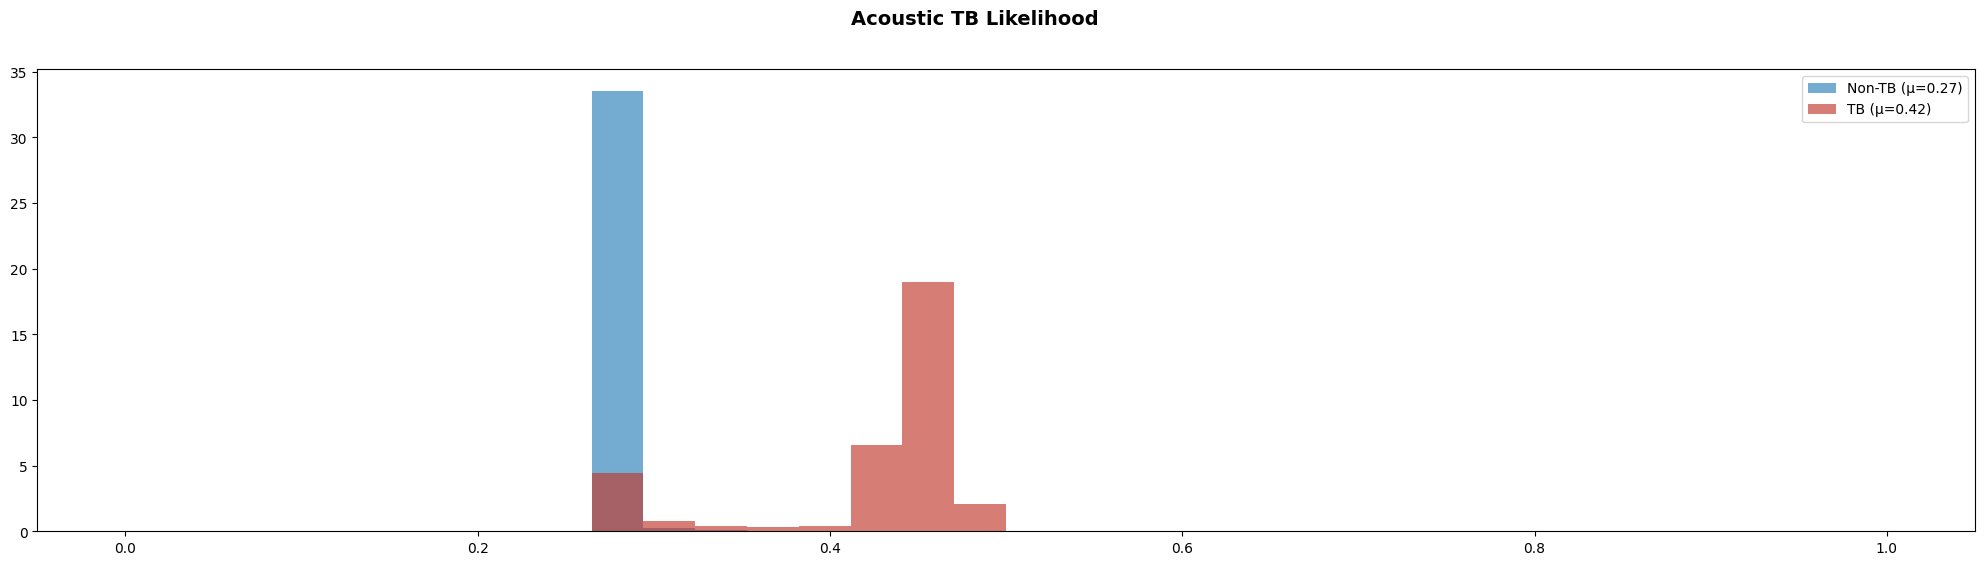

In [96]:
#######################################################
fig, axes = plt.subplots(1, 1, figsize=(25, 6))
fig.suptitle("Acoustic TB Likelihood", fontsize=14, fontweight="bold")
colors = {"TB": "#C0392B", "Non-TB": "#2980B9"}
bins = np.linspace(0, 1, 35)

scores = df_combine["tb_score"].values
tb_scores = scores[tb_mask]
nontb_scores = scores[~tb_mask]

ax = axes
ax.hist(nontb_scores, bins=bins, color=colors["Non-TB"], alpha=0.65, label=f"Non-TB (μ={nontb_scores.mean():.2f})", density=True)
ax.hist(tb_scores, bins=bins, color=colors["TB"], alpha=0.65, label=f"TB (μ={tb_scores.mean():.2f})", density=True)
ax.legend()

In [69]:
df_eval = df_combine[
    ~((df_combine["tb_score"] < 0.5) & (df_combine["disease_status"] == 1)) &
    (df_combine["db"] != 2)
].reset_index(drop=True)

In [71]:
summary, model_results = run_embedding_classification(
    df_eval,
    train_db=0,
    test_dbs=[1],
    label_col="disease_status",
)
summary

Training classifiers: 100%|██████████| 5/5 [02:12<00:00, 26.47s/it]


{'mean_auroc_all_models': 0.6913261789646501,
 'std_auroc_all_models': 0.01989862692969759,
 'mean_auroc_db1_all_models': 0.5123496198394157,
 'std_auroc_db1_all_models': 0.004337950574843675}

In [ ]:
all_scores = {}
variance_threshold = 0.95
method_reduction = "pca" # "umap" "pca"
n_components = 50 #20–50
#n_components, _ = _auto_pca_components(raw_emb, variance_threshold, 42)
N, D = raw_emb.shape

reducer = PCA(n_components=n_components, random_state=42)
reducer_umap = umap.UMAP(n_components=n_components, n_neighbors=min(15, N // 10), min_dist=0.1, metric="euclidean", n_jobs=-1, random_state=42)
emb_reduced = reducer.fit_transform(raw_emb)
emb_reduced_umap = reducer_umap.fit_transform(raw_emb)

tb_emb   = emb_reduced[tb_mask]
nontb_emb = emb_reduced[~tb_mask]

tb_emb_umap   = emb_reduced_umap[tb_mask]
nontb_emb_umap = emb_reduced_umap[~tb_mask]

In [ ]:
"""
k-Nearest Neighbor distance-based acoustic TB likelihood.

Intuition
---------
For each sample, compute:
    d_TB     = mean distance to its k nearest TB neighbors
    d_NonTB  = mean distance to its k nearest Non-TB neighbors

Score = d_NonTB / (d_TB + d_NonTB)
    → high score = closer to TB neighborhood = likely TB
    → low score  = closer to Non-TB neighborhood = likely Non-TB

Makes NO distributional assumptions. Captures non-linear, multi-modal
cluster structure. Each sample is judged by its local neighborhood,
not a global decision boundary.

Parameters
----------
Bigger K, More Spread to distribution, make it can overrlap each other
k : number of neighbors (15–25 works well for large datasets)
alpha : Balance Density of Each Class, Higher Mean TB ore have coverage, read Sigmoid Function
"""
all_scores["knn_euc"] = knn_tb_score(emb_reduced, tb_emb, nontb_emb, k_tb=20, k_nontb=20, alpha=20, metric="euclidean")
all_scores["knn_cos"] = knn_tb_score(emb_reduced, tb_emb, nontb_emb, k_tb=10, k_nontb=10, alpha=7, metric="cosine")

#######################################################
fig, axes = plt.subplots(1, 2, figsize=(25, 6))
fig.suptitle("Acoustic TB Likelihood", fontsize=14, fontweight="bold")
colors = {"TB": "#C0392B", "Non-TB": "#2980B9"}
bins = np.linspace(0, 1, 35)

scores = all_scores["knn_euc"]
tb_scores = scores[tb_mask]
nontb_scores = scores[~tb_mask]

ax = axes[0]
ax.hist(nontb_scores, bins=bins, color=colors["Non-TB"], alpha=0.65, label=f"Non-TB (μ={nontb_scores.mean():.2f})", density=True)
ax.hist(tb_scores, bins=bins, color=colors["TB"], alpha=0.65, label=f"TB (μ={tb_scores.mean():.2f})", density=True)
ax.legend()

scores = all_scores["knn_cos"]
tb_scores = scores[tb_mask]
nontb_scores = scores[~tb_mask]

ax = axes[1]
ax.hist(nontb_scores, bins=bins, color=colors["Non-TB"], alpha=0.65, label=f"Non-TB (μ={nontb_scores.mean():.2f})", density=True)
ax.hist(tb_scores, bins=bins, color=colors["TB"], alpha=0.65, label=f"TB (μ={tb_scores.mean():.2f})", density=True)
ax.legend()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
bins = np.linspace(0, 1, 30)

# ---- Left: DB0 ----
ax = axes[0]

nontb_scores0 = all_scores["knn_euc"][~tb_mask0]
acoustic_tb_scores0 = all_scores["knn_euc"][tb_mask0]

ax.hist(nontb_scores0, bins=bins, color="#2980B9", alpha=0.6, label="Non-TB", density=True)
ax.hist(acoustic_tb_scores0, bins=bins, color="#F39C12", alpha=0.7, label="Label-only-TB", density=True)

ax.set_xlabel("Acoustic TB Likelihood Score")
ax.set_ylabel("Density")
ax.set_title("DB0 Score Distribution")
ax.legend()

# ---- Right: DB1 ----
ax = axes[1]

nontb_scores1 = all_scores["knn_euc"][~tb_mask1]
acoustic_tb_scores1 = all_scores["knn_euc"][tb_mask1]

ax.hist(nontb_scores1, bins=bins, color="#2980B9", alpha=0.6, label="Non-TB", density=True)
ax.hist(acoustic_tb_scores1, bins=bins, color="#F39C12", alpha=0.7, label="Label-only-TB", density=True)

ax.set_xlabel("Acoustic TB Likelihood Score")
ax.set_ylabel("Density")
ax.set_title("DB1 Score Distribution")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
"""
Gaussian Mixture Model posterior: P(TB | x).

Intuition
---------
Fit a separate GMM on TB samples and on Non-TB samples.
Each GMM models the multi-modal, non-linear structure of its class.
Score = P(x | GMM_TB) / (P(x | GMM_TB) + P(x | GMM_NonTB))
        = Bayesian posterior P(TB | x) assuming equal class priors.

Unlike LDA, this:
    - Handles multi-modal distributions (multiple acoustic TB subtypes)
    - Captures non-linear cluster shapes via mixture of Gaussians
    - Gives a proper probabilistic score with Bayesian interpretation

n_components auto-selected via BIC if not provided.

Parameters
----------
n_components_tb    : GMM components for TB class (None = auto via BIC)
n_components_nontb : GMM components for Non-TB class (None = auto via BIC)
"""

gmm_tb = best_gmm(tb_emb, max_k=1, random_state=42)
gmm_nontb = best_gmm(nontb_emb, max_k=1, random_state=42)

# Log-likelihoods
log_p_tb    = gmm_tb.score_samples(emb_reduced)    # (N,) log P(x | TB)
log_p_nontb = gmm_nontb.score_samples(emb_reduced) # (N,) log P(x | Non-TB)

# # Stable log-sum-exp for posterior
# # P(TB|x) = exp(log_p_tb) / (exp(log_p_tb) + exp(log_p_nontb)) , The probability that the sample has TB given the observed data x
log_max = np.maximum(log_p_tb, log_p_nontb)
posterior_tb = np.exp(log_p_tb - log_max) / (np.exp(log_p_tb - log_max) + np.exp(log_p_nontb - log_max) + 1e-8)
posterior_tb = posterior_tb.astype(np.float32)
#posterior_tb = _posterior(log_p_tb, log_p_nontb)
all_scores["gmm"] = posterior_tb

#######################################################
fig, axes = plt.subplots(1, 1, figsize=(25, 6))
fig.suptitle("Acoustic TB Likelihood", fontsize=14, fontweight="bold")
colors = {"TB": "#C0392B", "Non-TB": "#2980B9"}
bins = np.linspace(0, 1, 35)

scores = all_scores["gmm"]
tb_scores = scores[tb_mask]
nontb_scores = scores[~tb_mask]

ax = axes
ax.hist(nontb_scores, bins=bins, color=colors["Non-TB"], alpha=0.65, label=f"Non-TB (μ={nontb_scores.mean():.2f})", density=True)
ax.hist(tb_scores, bins=bins, color=colors["TB"], alpha=0.65, label=f"TB (μ={tb_scores.mean():.2f})", density=True)
ax.legend()
plt.show()

In [ ]:
"""
LOF fitted on Non-TB only — anomaly w.r.t. Non-TB distribution.

High score → sample is isolated relative to its Non-TB neighborhood
            → likely not a typical Non-TB cough → possibly TB.
"""
n_neighbors = 70

lof_tb = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True, n_jobs=-1)
lof_ntb = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True, n_jobs=-1)

lof_tb.fit(tb_emb)
lof_ntb.fit(nontb_emb)

score_tb = lof_tb.score_samples(emb_reduced)      # density relative to TB
score_ntb = lof_ntb.score_samples(emb_reduced)    # density relative to Non-TB

margin = score_tb - score_ntb

alpha = 16
scores = 1 / (1 + np.exp(-alpha * margin))           # sigmoid shaping
all_scores["lof_margin"] = _minmax_normalize(scores)

#######################################################
fig, axes = plt.subplots(1, 1, figsize=(25, 6))
fig.suptitle("Acoustic TB Likelihood", fontsize=14, fontweight="bold")
colors = {"TB": "#C0392B", "Non-TB": "#2980B9"}
bins = np.linspace(0, 1, 35)

scores = all_scores["lof_margin"]
tb_scores = scores[tb_mask]
nontb_scores = scores[~tb_mask]

ax = axes
ax.hist(nontb_scores, bins=bins, color=colors["Non-TB"], alpha=0.65, label=f"Non-TB (μ={nontb_scores.mean():.2f})", density=True)
ax.hist(tb_scores, bins=bins, color=colors["TB"], alpha=0.65, label=f"TB (μ={tb_scores.mean():.2f})", density=True)
ax.legend()
plt.show()

In [ ]:
# Per-method breakdown
for m, s in all_scores.items():
    if m == "ensemble": continue
    print(f"  [{m}] TB: {s[tb_mask].mean():.3f} ± {s[tb_mask].std():.3f} | " f"Non-TB: {s[~tb_mask].mean():.3f} ± {s[~tb_mask].std():.3f}")

In [ ]:
# Simple average — each method captures different aspects
scores_ensembles =  np.mean(list(all_scores.values()), axis=0) #np.mean([all_scores["knn_euc"], all_scores["knn_cos"]], axis=0) # np.mean(list(all_scores.values()), axis=0) # np.mean([all_scores["knn_cos"], all_scores["gmm"]], axis=0) np.mean([all_scores["knn_euc"], all_scores["gmm"]], axis=0) #
all_scores["ensemble"] = scores_ensembles
acoustic_scores = scores_ensembles

print(f"  Ensemble TB mean score:     {acoustic_scores[tb_mask].mean():.3f} ± {acoustic_scores[tb_mask].std():.3f}")
print(f"  Ensemble Non-TB mean score: {acoustic_scores[~tb_mask].mean():.3f} ± {acoustic_scores[~tb_mask].std():.3f}")

In [ ]:
from scipy.stats import mannwhitneyu

methods = list(all_scores.keys()) #[m for m in ["kde", "knn", "gmm", "ocsvm", "lof", "ensemble"] if m in all_scores] # ["ensemble"]
n = len(methods)

fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))#plt.subplots(2, n, figsize=(4 * n, 8)) plt.subplots(2, n, figsize=(14, 8))
fig.suptitle("Acoustic TB Likelihood", fontsize=14, fontweight="bold") #suptitle("Acoustic TB Likelihood — Method Comparison", fontsize=14, fontweight="bold", y=1.01)

method_labels = {"kde": "One-Class KDE\n(Non-TB density anomaly)",
                     "knn": "k-NN Distance\n(local neighborhood)",
                     "gmm": "GMM Posterior\nP(TB|x)",
                     "ensemble": "Ensemble\n(average of 3)"}
# method_labels.get(method, method)
colors = {"TB": "#C0392B", "Non-TB": "#2980B9"}

for col, method in enumerate(methods):
    scores = all_scores[method]
    tb_scores    = scores[tb_mask]
    nontb_scores = scores[~tb_mask]

    # Row 0: distribution
    ax = axes[0, col]
    bins = np.linspace(0, 1, 35)
    ax.hist(nontb_scores, bins=bins, color=colors["Non-TB"], alpha=0.65,
            label=f"Non-TB (μ={nontb_scores.mean():.2f})", density=True)
    ax.hist(tb_scores, bins=bins, color=colors["TB"], alpha=0.65,
            label=f"TB (μ={tb_scores.mean():.2f})", density=True)

    # AUC-like separation: how well does this score separate classes?
    from sklearn.metrics import roc_auc_score
    try:
        auc = roc_auc_score(tb_mask.astype(int), scores)
        auc = max(auc, 1 - auc)  # always report > 0.5
    except Exception:
        auc = float("nan")

    ax.set_title(f"{method}\nAUROC = {auc:.3f}",
                    fontsize=10, fontweight="bold")
    ax.set_xlabel("Score", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)

    # Row 1: box plot per class
    ax = axes[1, col]
    data_plot = [nontb_scores, tb_scores]
    bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", linewidth=2))
    for patch, color in zip(bp["boxes"], [colors["Non-TB"], colors["TB"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Non-TB", "TB"], fontsize=10)
    ax.set_ylabel("Score", fontsize=9)

    # Statistical test
    stat, pval = mannwhitneyu(tb_scores, nontb_scores, alternative="two-sided")
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
    ymax = max(tb_scores.max(), nontb_scores.max())
    ax.annotate("", xy=(2, ymax * 1.05), xytext=(1, ymax * 1.05),
                arrowprops=dict(arrowstyle="-", color="black"))
    ax.text(1.5, ymax * 1.07, f"p={pval:.2e} {sig}",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()
fig.savefig(
    "docs/unsupervised_distri/figures/TB Likelihood.png",
    dpi=300,
    bbox_inches="tight"
)

In [ ]:
filter_perdb = False
df_combine["acoustic_tb_score"] = acoustic_scores

if filter_perdb:
    df_db0 = df_combine[df_combine['db'] == 0].copy().reset_index(drop=True)
    df_db1 = df_combine[df_combine['db'] == 1].copy().reset_index(drop=True)

    tb_mask0 = df_db0["disease_status"] == 1
    tb_mask1 = df_db1["disease_status"] == 1

    df_db0["disease_status_rev"] = 0
    threshold_0 = df_db0[tb_mask0]['acoustic_tb_score'].median()
    #threshold_0 = np.percentile(df_db0[~tb_mask0]['acoustic_tb_score'].values, 99) + 0.05
    #threshold_0 = np.percentile(df_db0[tb_mask0]['acoustic_tb_score'].values, 35) 
    df_db0.loc[tb_mask0, "disease_status_rev"] = np.where(
        df_db0.loc[tb_mask0, "acoustic_tb_score"].values >= threshold_0, 1, 2
    )

    df_db1["disease_status_rev"] = 0
    threshold_1 = df_db1[tb_mask1]['acoustic_tb_score'].median()
    df_db1.loc[tb_mask1, "disease_status_rev"] = np.where(
        df_db1.loc[tb_mask1, "acoustic_tb_score"].values >= threshold_1, 1, 2
    )

    df_rev = pd.concat([df_db0[["path_file", "disease_status_rev"]], df_db1[["path_file", "disease_status_rev"]]])
    df_combine["disease_status_rev"] = (df_combine["path_file"].map(df_rev.set_index("path_file")["disease_status_rev"]))
else:
    tb_mask0 = df_combine["disease_status"] == 1
    df_combine["disease_status_rev"] = 0
    threshold_0 = df_combine[tb_mask0]['acoustic_tb_score'].median()
    df_combine.loc[tb_mask0, "disease_status_rev"] = np.where(
        df_combine.loc[tb_mask0, "acoustic_tb_score"].values >= threshold_0, 1, 2
    )

tb_mask_df = df_combine["disease_status"] == 1
n_acoustic = (df_combine[tb_mask_df]["disease_status_rev"] == 1).sum()
n_labelonly = (df_combine[tb_mask_df]["disease_status_rev"] == 2).sum()
print(f"  Acoustic-TB:    {n_acoustic} ({n_acoustic/tb_mask_df.sum()*100:.1f}%)")
print(f"  Label-only-TB:  {n_labelonly} ({n_labelonly/tb_mask_df.sum()*100:.1f}%)\n")

print(f"  Acoustic-TB:    {df_combine[df_combine["disease_status_rev"] == 1]['acoustic_tb_score'].mean()}")
print(f"  Label-only-TB:  {df_combine[df_combine["disease_status_rev"] == 2]['acoustic_tb_score'].mean()}")

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))
bins = np.linspace(0, 1, 30)

# ---- Left: DB0 ----
ax = axes

tb_mask0 = df_combine["disease_status"] == 1
nontb_scores0 = df_combine['acoustic_tb_score'].values[~tb_mask0]
acoustic_tb_scores0 = df_combine.loc[df_combine["disease_status_rev"] == 1, "acoustic_tb_score"].values
labelonly_tb_scores0 = df_combine.loc[df_combine["disease_status_rev"] == 2, "acoustic_tb_score"].values

ax.hist(nontb_scores0, bins=bins, color="#2980B9", alpha=0.6, label="Non-TB", density=True)
ax.hist(acoustic_tb_scores0, bins=bins, color="#C0392B", alpha=0.7, label="Acoustic-TB", density=True)
ax.hist(labelonly_tb_scores0, bins=bins, color="#F39C12", alpha=0.7, label="Label-only-TB", density=True)
ax.axvline(threshold_0, color="black", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold_0:.2f})")

ax.set_xlabel("Acoustic TB Likelihood Score")
ax.set_ylabel("Density")
ax.set_title("Score Distribution")
ax.legend()
plt.show()

# plt.tight_layout()
# fig.savefig(
#     "docs/unsupervised_distri/figures/TB Likelihood - After plit.png",
#     dpi=300,
#     bbox_inches="tight"
# )

#################################################################################################
df_tb_only = df_combine[df_combine["db"] != 2].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bins = np.linspace(0, 1, 30)

tb_mask0 = (df_tb_only["disease_status"] == 1) & (df_tb_only["db"] == 0)
tb_mask1 = (df_tb_only["disease_status"] == 1) & (df_tb_only["db"] == 1)

# ---- Left: DB0 ----
ax = axes[0]

nontb_scores0 = df_tb_only[~tb_mask0]['acoustic_tb_score'].values
acoustic_tb_scores0 = df_tb_only[tb_mask0].loc[df_tb_only["disease_status_rev"] == 1, "acoustic_tb_score"].values
labelonly_tb_scores0 = df_tb_only[tb_mask0].loc[df_tb_only["disease_status_rev"] == 2, "acoustic_tb_score"].values

ax.hist(nontb_scores0, bins=bins, color="#2980B9", alpha=0.6, label="Non-TB", density=True)
ax.hist(acoustic_tb_scores0, bins=bins, color="#C0392B", alpha=0.7, label="Acoustic-TB", density=True)
ax.hist(labelonly_tb_scores0, bins=bins, color="#F39C12", alpha=0.7, label="Label-only-TB", density=True)

ax.set_xlabel("Acoustic TB Likelihood Score")
ax.set_ylabel("Density")
ax.set_title("DB0 Score Distribution")
ax.legend()

# ---- Right: DB1 ----
ax = axes[1]

nontb_scores1 = df_tb_only[~tb_mask1]['acoustic_tb_score'].values
acoustic_tb_scores1 = df_tb_only[tb_mask1].loc[df_tb_only["disease_status_rev"] == 1, "acoustic_tb_score"].values
labelonly_tb_scores1 = df_tb_only[tb_mask1].loc[df_tb_only["disease_status_rev"] == 2, "acoustic_tb_score"].values

ax.hist(nontb_scores1, bins=bins, color="#2980B9", alpha=0.6, label="Non-TB", density=True)
ax.hist(acoustic_tb_scores1, bins=bins, color="#C0392B", alpha=0.7, label="Acoustic-TB", density=True)
ax.hist(labelonly_tb_scores1, bins=bins, color="#F39C12", alpha=0.7, label="Label-only-TB", density=True)

ax.set_xlabel("Acoustic TB Likelihood Score")
ax.set_ylabel("Density")
ax.set_title("DB1 Score Distribution")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
df_eval = (
    df_combine[
        (df_combine["disease_status_rev"] != 2) & (df_combine["db"] != 2)
    ]
    .copy()
    .reset_index(drop=True)
)
summary, model_results = run_embedding_classification(
    df_eval,
    train_db=0,
    test_dbs=[1],
    label_col="disease_status_rev",
)
summary

In [ ]:
summary, model_results = run_embedding_classification(
    df_eval,
    train_db=1,
    test_dbs=[0],
    label_col="disease_status_rev",
)
summary

In [ ]:
summary, model_results = run_embedding_classification(
    df_eval,
    train_db=[0, 1],
    label_col="disease_status_rev",
)
summary

In [ ]:
df_tosave = df_combine.copy()
df_tosave = df_tosave.drop(columns=["embed", "acoustic_tb_score", "disease_status"], errors="ignore")
df_tosave = df_tosave.rename(columns={"disease_status_rev": "disease_status"}, errors="ignore")
df_tosave['split'] = 'train'
df_tosave = df_tosave[['path_file', 'participant', 'gender', 'disease_status', 'weight_loss', 'hemoptysis', 'smoker', 'night_sweats', 'split', 'db']]

In [ ]:
df_tosave = df_tosave[df_tosave['disease_status'] != 2]

In [ ]:
df_tosave

In [ ]:
df_tosave[df_tosave['db'] == 0].reset_index(drop=True).to_csv("data/metadata_coda_solicited_filtered.csv.train", index=False)
df_tosave[df_tosave['db'] == 1].reset_index(drop=True).to_csv("data/metadata_cirdz_filtered.csv.train", index=False)

## Evaluate

In [ ]:
COLORS = ["#C0392B", "#2980B9", "#27AE60", "#8E44AD"]

def plot_cross_dataset_roc(cross_results: dict, save_path: str = None):
    """
    ROC curves for all cross-dataset directions, one panel per direction.
    All classifiers shown per panel.
    """
    directions = list(cross_results.keys())
    n = len(directions)
    if n == 0:
        return

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle("Cross-Dataset Generalization — ROC Curves",
                 fontsize=14, fontweight="bold")

    for ax, direction in zip(axes, directions):
        clf_results = cross_results[direction]
        for (clf_name, res), color in zip(clf_results.items(), COLORS):
            ax.plot(res["fpr"], res["tpr"], color=color, linewidth=2,
                    label=f"{clf_name} (AUROC={res['auroc']:.3f})")

        ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
        ax.set_title(f"Train → Test:\n{direction}", fontsize=11, fontweight="bold")
        ax.set_xlabel("False Positive Rate", fontsize=10)
        ax.set_ylabel("True Positive Rate", fontsize=10)
        ax.legend(fontsize=8, loc="lower right")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
        _style_ax(ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.close()